In [1]:
import numpy as np
import pandas as pd


## EDA ON DIM_CONTENT

In [3]:
df = pd.read_csv('Dim_content.csv')
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   content_key        200 non-null    int64  
 1   content_id         200 non-null    object 
 2   title              200 non-null    object 
 3   genre              200 non-null    object 
 4   sub_genre          200 non-null    object 
 5   release_year       200 non-null    int64  
 6   language           200 non-null    object 
 7   content_type       200 non-null    object 
 8   imdb_rating        200 non-null    float64
 9   duration_minutes   200 non-null    int64  
 10  age_rating         200 non-null    object 
 11  country_of_origin  200 non-null    object 
 12  is_original        200 non-null    bool   
 13  total_seasons      88 non-null     float64
dtypes: bool(1), float64(2), int64(3), object(8)
memory usage: 20.6+ KB


,content_key,release_year,imdb_rating,duration_minutes,total_seasons
count,200.000000,200.000000,200.000000,200.000000,88.000000
mean,100.500000,2011.135000,6.779000,104.585000,4.318182
std,57.879185,6.965585,1.553229,49.416523,2.375863
min,1.000000,2000.000000,4.000000,21.000000,1.000000
25%,50.750000,2005.000000,5.400000,57.750000,2.000000
50%,100.500000,2011.000000,6.900000,110.500000,4.000000
75%,150.250000,2017.000000,8.025000,149.000000,6.000000
max,200.000000,2023.000000,9.500000,179.000000,8.000000


#### Missing values

In [5]:
df.isnull().sum()

content_key            0
content_id             0
title                  0
genre                  0
sub_genre              0
release_year           0
language               0
content_type           0
imdb_rating            0
duration_minutes       0
age_rating             0
country_of_origin      0
is_original            0
total_seasons        112
dtype: int64

#### Univariate analysis

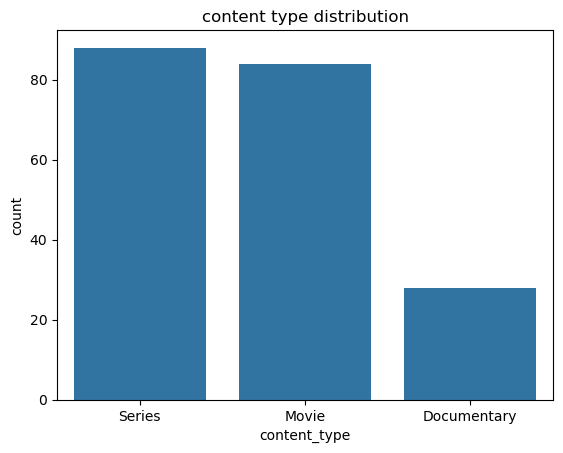

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

### CONTENT TYPE DISTRIBUTION
sns.countplot(data=df,x='content_type')
plt.title('content type distribution')
plt.show()

### BUSINESS INSIGHTS(Content Type Distribution):
- Series are most watched content compared to movies and documentary.
- Documentary form a small portion in this.

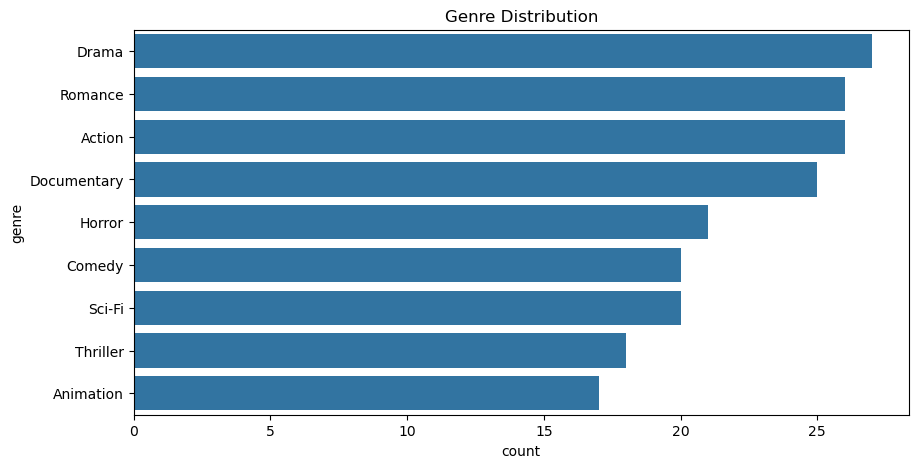

In [12]:
### GENRE DISTRIBUTION

plt.figure(figsize=(10,5))

sns.countplot(
    data =df,
    y = 'genre',
    order = df['genre'].value_counts().index
)

plt.title('Genre Distribution')
plt.show()

#### BUSINESS INSIGHTS(Genre Distribution):
- Most watched genre is "Drama".
- Least watched genre is "Animation".

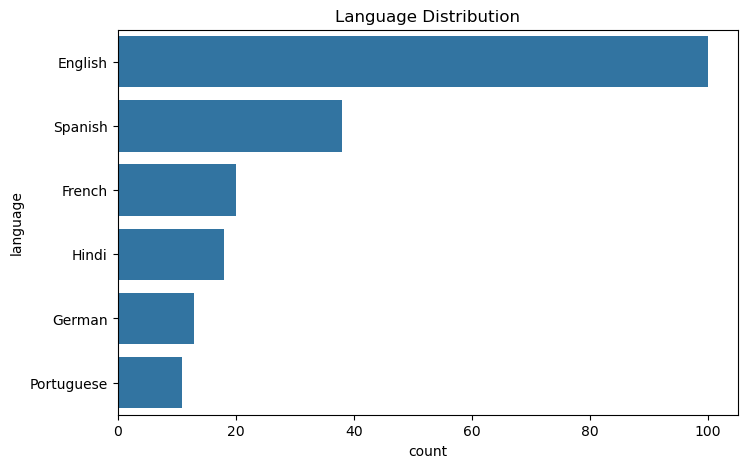

In [14]:
### LANGUAGE DISTRIBUTION
plt.figure(figsize=(8,5))

sns.countplot(
    data = df,
    y = 'language',
    order = df['language'].value_counts().index
)
plt.title('Language Distribution')
plt.show()


#### BUSINESS INSIGHTS(Language Distribution):
- Most watched language is ""English" followed by "Spanish".
- Least watched language is "Portugese".

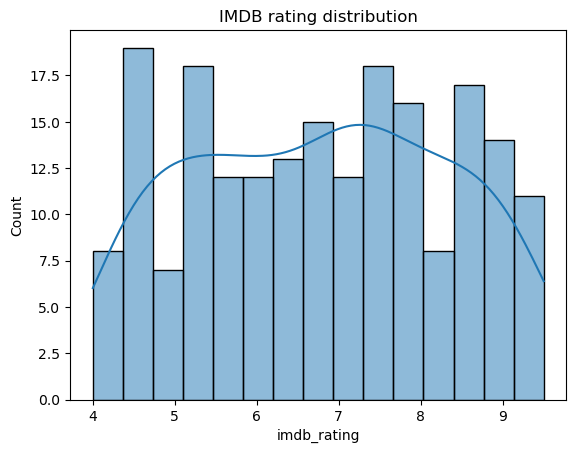

In [16]:
## IMDB RATING DISTRIBUTION
sns.histplot(df['imdb_rating'],bins = 15,kde = True)
plt.title('IMDB rating distribution')
plt.show()

#### BUSINESS INSIGHTS(IMDB rating distribution):
- IMDB of the content mostly lies between 7 and 8.

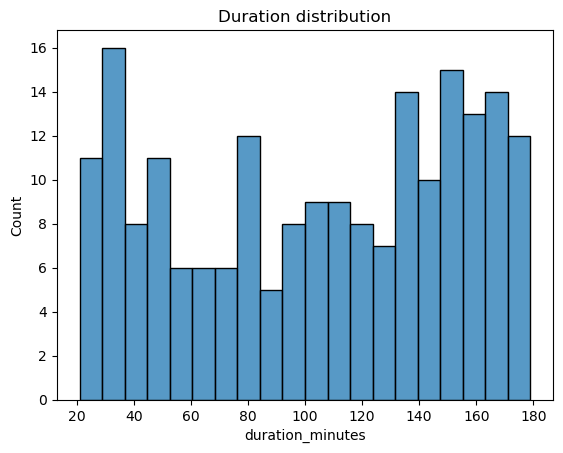

In [18]:
## DURATION DISTRIBUTION
sns.histplot(df['duration_minutes'],bins = 20)

plt.title('Duration distribution')
plt.show()

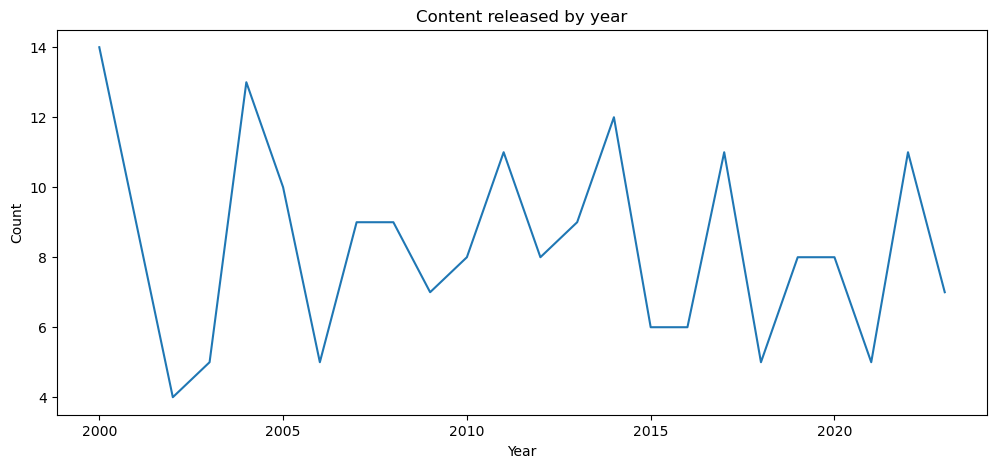

In [19]:
yearly_content = df['release_year'].value_counts().sort_index()

plt.figure(figsize=(12,5))

yearly_content.plot()

plt.title("Content released by year")
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

#### BIVARIATE ANALYSIS

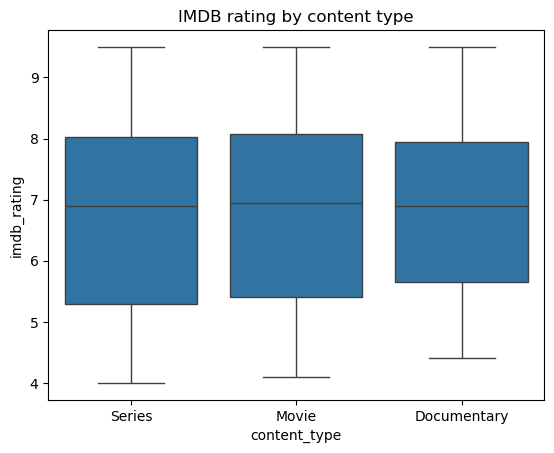

In [21]:
## IMDB rating by content type
sns.boxplot(
    data = df,
    x = 'content_type',
    y = 'imdb_rating'
)

plt.title('IMDB rating by content type')
plt.show()

#### BUSINESS INSIGHTS(IMDB rating by content type):
- All the genre have similar higher rating whereas series starts with lowest rating.

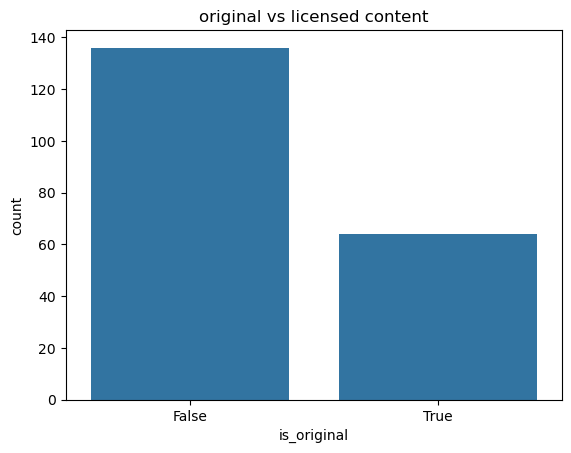

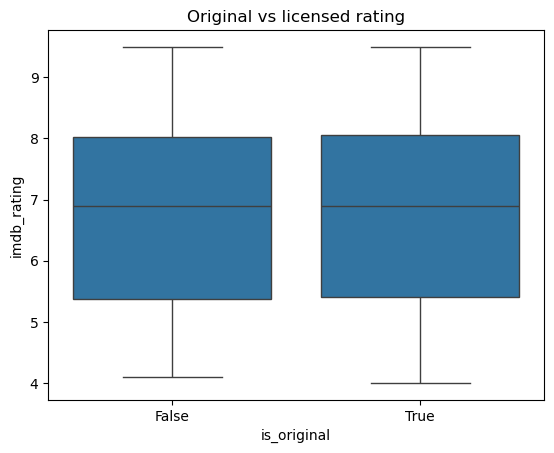

In [24]:
## ORIGINAL VS NON-ORIGINAL CONTENT
sns.countplot(data=df,x = 'is_original')
plt.title('original vs licensed content')
plt.show()

sns.boxplot(data = df,x = 'is_original',y = 'imdb_rating')
plt.title("Original vs licensed rating")
plt.show()

#### BUSINESS INSIGHTS(Original vs licensed rating):
- Both have similar imdb ratings.

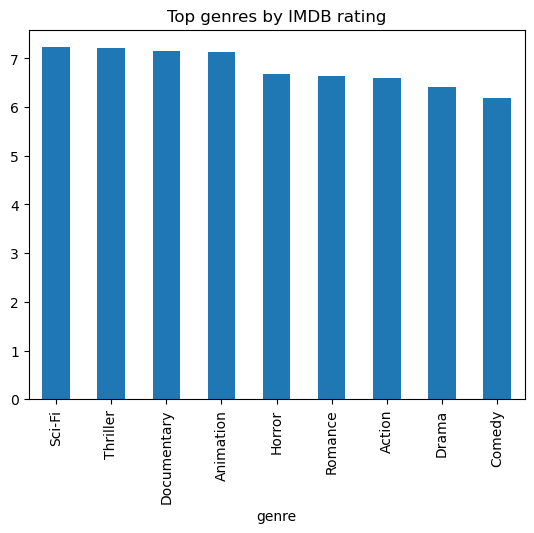

In [28]:
## TOP GENRES BY RATING
genre_rating = (df.groupby('genre')['imdb_rating'].mean().sort_values(ascending=False))

genre_rating.plot(kind='bar')
plt.title('Top genres by IMDB rating')
plt.show()

#### BUSINESS INSIGHTS(Top genre by IMDB rating):
- genre with highest IMDB rating are Sci-Fi.
- Genre with least IMDB rating is Comedy.

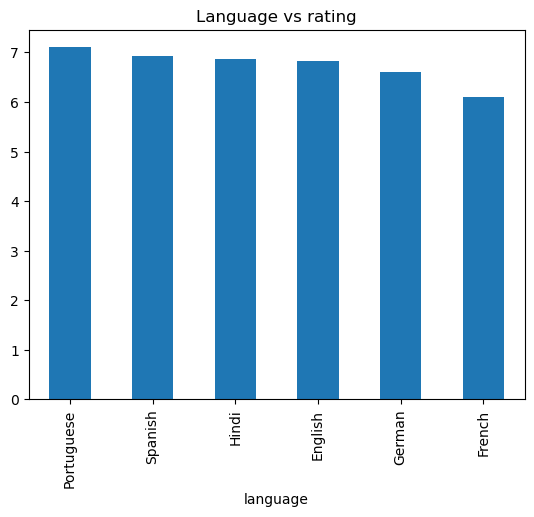

In [32]:
#### LANGUAGE VS RATING
language_rating = (df.groupby('language')['imdb_rating'].mean().sort_values(ascending=False))
language_rating.plot(kind = 'bar')
plt.title('Language vs rating')
plt.show()

#### BUSINESS INSIGHTS(Language vs ratings):
- Language with highest IMDB rating content is Porugese.
- Language with least IMDB content is French.

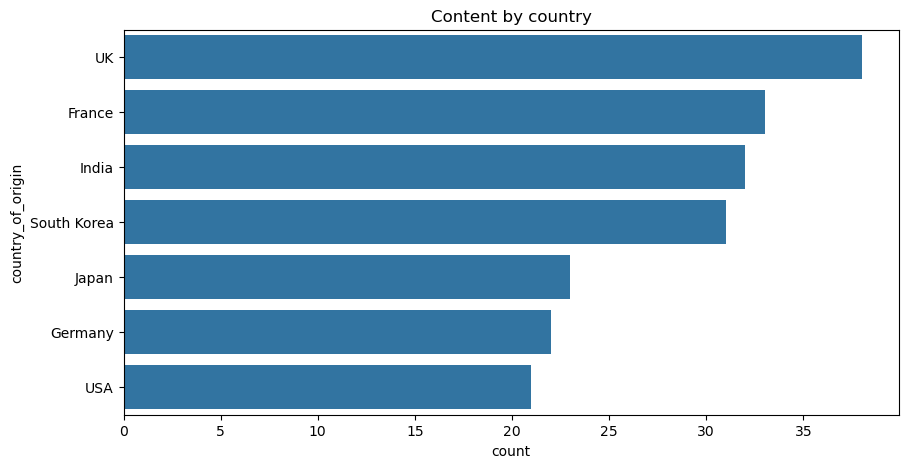

In [36]:
## COUNTRY ANALYSIS
plt.figure(figsize=(10,5))

sns.countplot(data = df,y= 'country_of_origin',order = df['country_of_origin'].value_counts().index)

plt.title('Content by country')
plt.show()

#### BUSINESS INSIGHTS(Content by country):
- Most of the content is produced by UK.
- US has less content produced. 

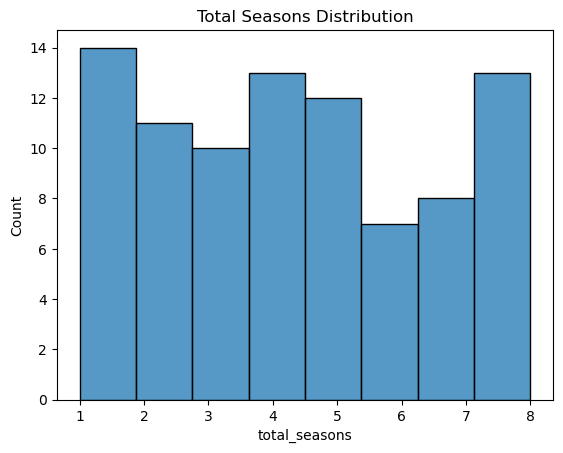

In [39]:
## SERIES ANALYSIS
series_df = df[df['content_type']=='Series']

## SEASONS DISTRIBUTION
sns.histplot(series_df['total_seasons'])
plt.title('Total Seasons Distribution')
plt.show()

#### BUSINESS INSIGHTS(Total Seasons Distribution):
- Most of the series have 1-2 seasons.
- Series with 5-7 seasons are very low.

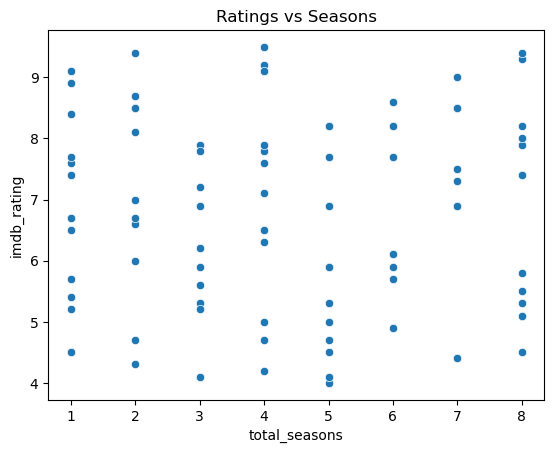

In [42]:
#### RATING vs SEASONS

sns.scatterplot(data = df,
               x = 'total_seasons',
               y = 'imdb_rating'
               )
plt.title('Ratings vs Seasons')
plt.show()

#### BUSINESS INSIGHTS(Total seasons vs IMDB ratings):
- We can obseerve that longer running series have higher IMDB ratings.

#### MULTIVARIATE ANALYSIS

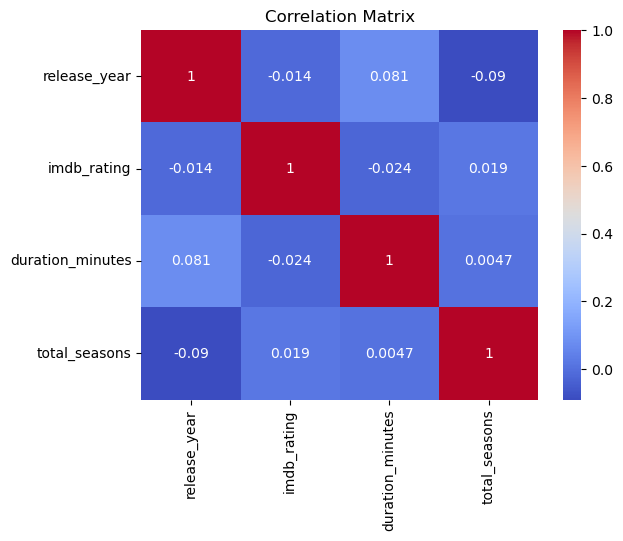

In [49]:
## CORRELATION ANALYSIS
num_cols = [
    'release_year',
    'imdb_rating',
    'duration_minutes',
    'total_seasons'
]

corr = df[num_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

In [50]:
df.to_csv('Dim_content_cleaned.csv',index=False)

#### FINAL INSIGHTS:
- "Correlation analysis revealed no strong linear relationships among release year, IMDb rating, duration, and total seasons (|r| < 0.1). This suggests that content quality and engagement characteristics are influenced more by categorical factors such as genre, language, content type, and originality rather than simple numerical attributes."

## EDA ON DIM_DATE

In [55]:
df = pd.read_csv('Dim_date.csv')
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date_key      365 non-null    int64 
 1   full_date     365 non-null    object
 2   day           365 non-null    int64 
 3   month         365 non-null    int64 
 4   month_name    365 non-null    object
 5   quarter       365 non-null    int64 
 6   year          365 non-null    int64 
 7   day_of_week   365 non-null    object
 8   week_number   365 non-null    int64 
 9   weekend_flag  365 non-null    bool  
 10  is_holiday    365 non-null    bool  
dtypes: bool(2), int64(6), object(3)
memory usage: 26.5+ KB


,date_key,day,month,quarter,year,week_number
count,365.000000,365.000000,365.000000,365.000000,365.0,365.000000
mean,183.000000,15.720548,6.526027,2.509589,2023.0,26.569863
std,105.510663,8.808321,3.452584,1.118300,0.0,15.067565
min,1.000000,1.000000,1.000000,1.000000,2023.0,1.000000
25%,92.000000,8.000000,4.000000,2.000000,2023.0,14.000000
50%,183.000000,16.000000,7.000000,3.000000,2023.0,27.000000
75%,274.000000,23.000000,10.000000,4.000000,2023.0,40.000000
max,365.000000,31.000000,12.000000,4.000000,2023.0,52.000000


In [57]:
df['full_date'] = pd.to_datetime(df['full_date'])

In [59]:
df.isnull().sum()

date_key        0
full_date       0
day             0
month           0
month_name      0
quarter         0
year            0
day_of_week     0
week_number     0
weekend_flag    0
is_holiday      0
dtype: int64

#### DAY OF WEEK DISTRIBUTION

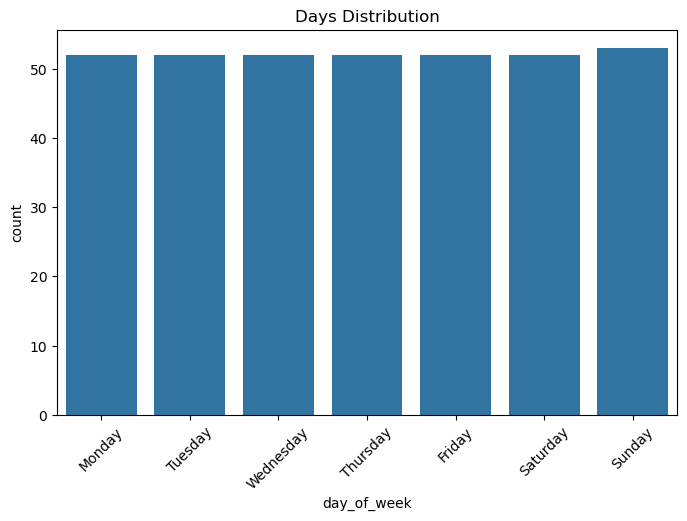

In [62]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='day_of_week',
    order=[
        'Monday','Tuesday','Wednesday',
        'Thursday','Friday','Saturday','Sunday'
    ]
)

plt.xticks(rotation=45)
plt.title('Days Distribution')
plt.show()

#### MONTH DISTRIBUTION

In [65]:
month_counts = df['month_name'].value_counts()

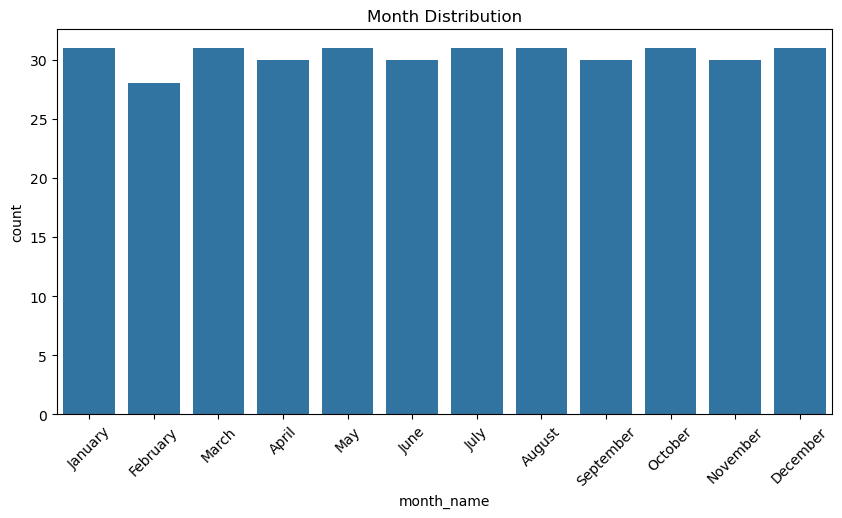

In [67]:
plt.figure(figsize=(10,5))

sns.countplot(data = df, x = 'month_name',
             order = [ 'January','February','March','April',
        'May','June','July','August',
        'September','October','November','December']
             )
plt.xticks(rotation=45)
plt.title('Month Distribution')
plt.show()

#### QUARTER DISTRIBUTION

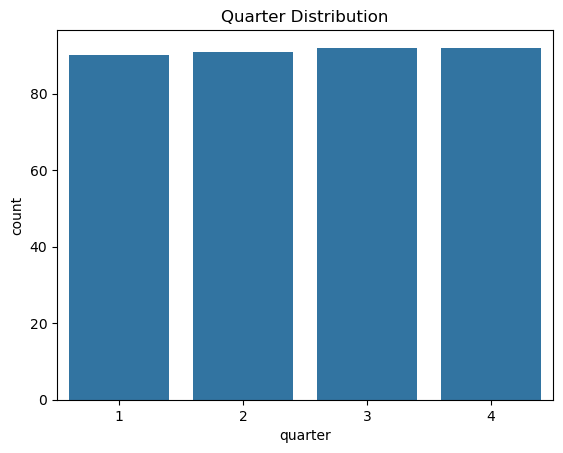

In [70]:
sns.countplot(data = df,x = 'quarter')
plt.title('Quarter Distribution')
plt.show()

#### WEEKEND VS WEEKDAY

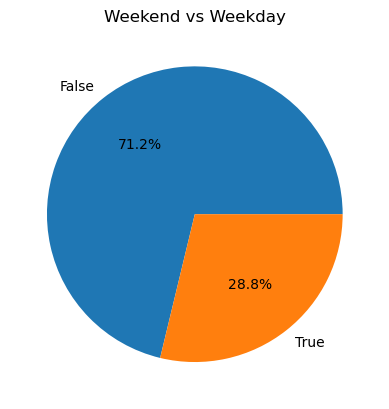

In [73]:
df['weekend_flag'].value_counts()

df['weekend_flag'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Weekend vs Weekday')
plt.ylabel('')
plt.show()

#### HOLIDAY ANALYSIS

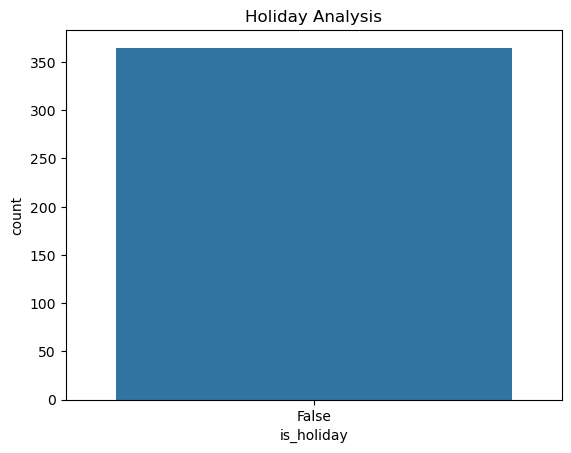

In [76]:
df['is_holiday'].value_counts()

sns.countplot(data = df,x = 'is_holiday')
plt.title('Holiday Analysis')
plt.show()

#### WEEK NUMBER DISTRIBUTION

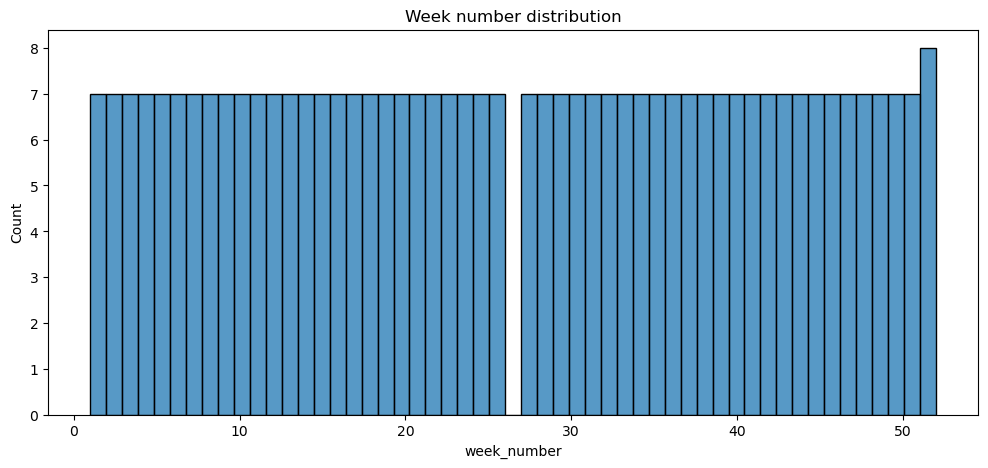

In [79]:
plt.figure(figsize=(12,5))

sns.histplot(df['week_number'],bins = 53)
plt.title('Week number distribution')
plt.show()

#### CORRELATION ANALYISIS

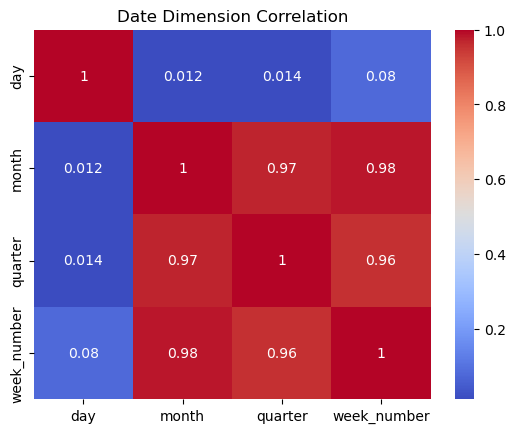

In [82]:
num_columns = ['day','month','quarter','week_number']
corr = df[num_columns].corr()

sns.heatmap(corr,annot = True,cmap = 'coolwarm')
plt.title('Date Dimension Correlation')
plt.show()

#### WEEKEND PATTERN BY MONTH

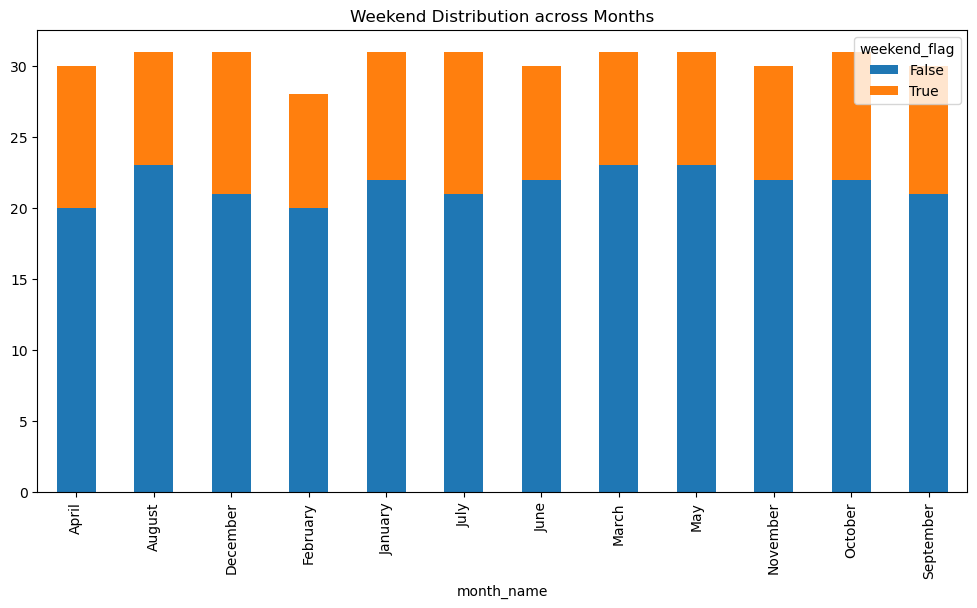

In [85]:
weekend_month = pd.crosstab(df['month_name'],df['weekend_flag'])

weekend_month.plot(kind = 'bar',stacked = True,figsize = (12,6))
plt.title('Weekend Distribution across Months')
plt.show()

#### HOLIDAY DISTRIBUTION ACROSS MONTHS

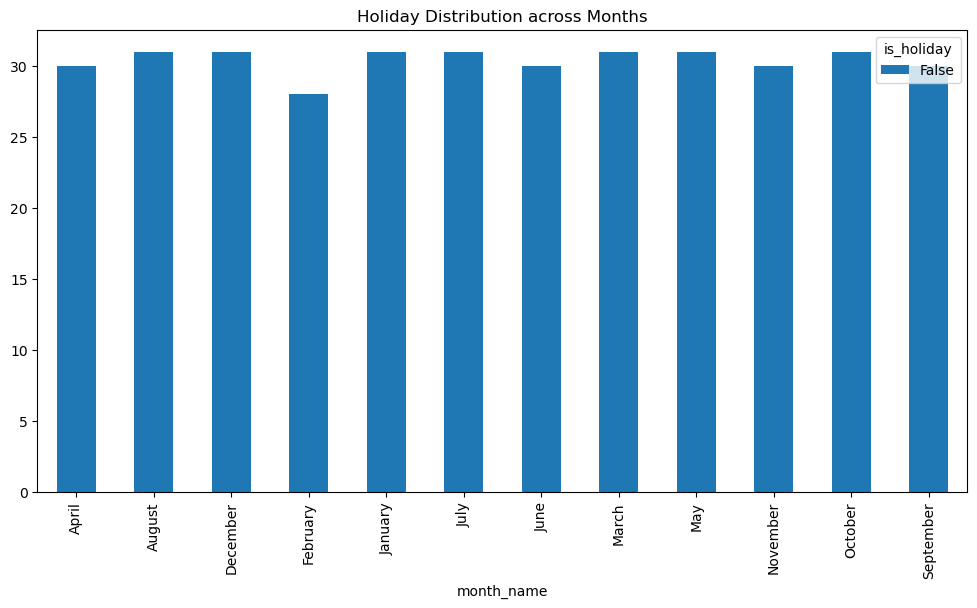

In [88]:
holiday_month = pd.crosstab(df['month_name'],df['is_holiday'])

holiday_month.plot(kind = 'bar', stacked = True,figsize=(12,6))
plt.title('Holiday Distribution across Months')
plt.show()

In [89]:
df.to_csv('Dim_Date_cleaned.csv',index=False)

## EDA ON DIM_DEVICE

In [91]:
df = pd.read_csv('Dim_device.csv')
df.info()
df.describe(include = 'all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   device_key            4 non-null      int64 
 1   device_type           4 non-null      object
 2   operating_system      4 non-null      object
 3   screen_size_category  4 non-null      object
 4   supports_hd           4 non-null      bool  
 5   supports_uhd          4 non-null      bool  
dtypes: bool(2), int64(1), object(3)
memory usage: 268.0+ bytes


,device_key,device_type,operating_system,screen_size_category,supports_hd,supports_uhd
count,4.000000,4,4,4,4,4
unique,NaN,4,4,3,1,2
top,NaN,Mobile,iOS/Android,Medium,True,False
freq,NaN,1,1,2,4,2
mean,2.500000,NaN,NaN,NaN,NaN,NaN
std,1.290994,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN
25%,1.750000,NaN,NaN,NaN,NaN,NaN
50%,2.500000,NaN,NaN,NaN,NaN,NaN
75%,3.250000,NaN,NaN,NaN,NaN,NaN


In [92]:
df

,device_key,device_type,operating_system,screen_size_category,supports_hd,supports_uhd
0,1,Mobile,iOS/Android,Small,True,False
1,2,Smart TV,Tizen/WebOS,Large,True,True
2,3,Tablet,iPadOS/Android,Medium,True,False
3,4,Desktop,Windows/macOS,Medium,True,True


In [97]:
df.isnull().sum()

device_key              0
device_type             0
operating_system        0
screen_size_category    0
supports_hd             0
supports_uhd            0
dtype: int64

#### DEVICE TYPE DISTRIBUTION

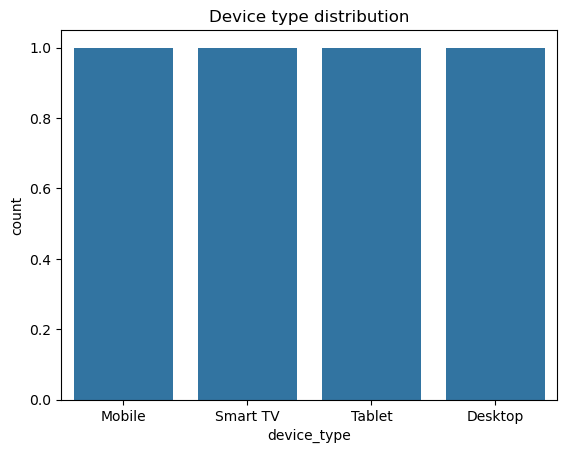

In [100]:
sns.countplot(data = df,x = 'device_type')
plt.title('Device type distribution')
plt.show()

#### SCREEN SIZE ANALYSIS

In [103]:
df['screen_size_category'].value_counts()

screen_size_category
Medium    2
Small     1
Large     1
Name: count, dtype: int64

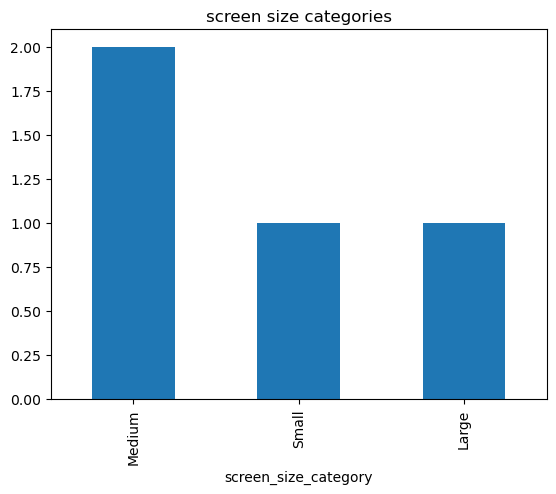

In [105]:
df['screen_size_category'].value_counts().plot(kind = 'bar')
plt.title('screen size categories')
plt.show()

#### UHD SUPPORT ANALYSIS

In [108]:
df['supports_uhd'].value_counts()

supports_uhd
False    2
True     2
Name: count, dtype: int64

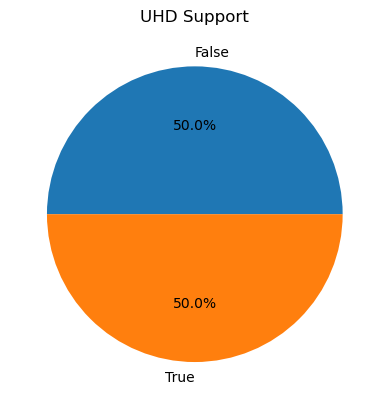

In [110]:
df['supports_uhd'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel('')
plt.title("UHD Support")
plt.show()

#### DEVICE VS UHD CAPABILITY

In [113]:
pd.crosstab(df['device_type'],df['supports_uhd'])

supports_uhd,False,True
device_type,,
Desktop,0,1
Mobile,1,0
Smart TV,0,1
Tablet,1,0


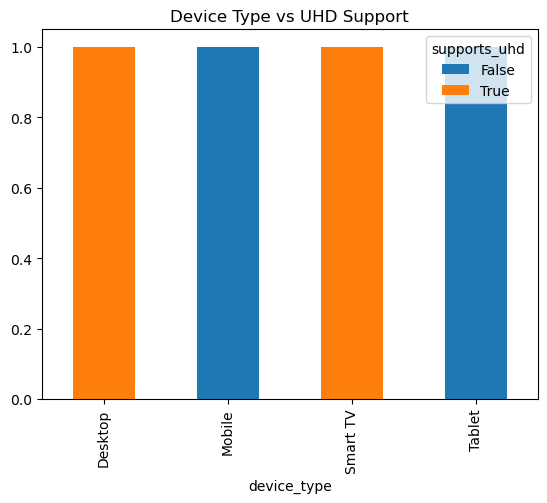

In [115]:
device_uhd = pd.crosstab(
    df['device_type'],
    df['supports_uhd']
)

device_uhd.plot(
    kind='bar',
    stacked=True
)

plt.title("Device Type vs UHD Support")
plt.show()

#### DEVICE VS SCREEN SIZE

In [118]:
pd.crosstab(df['device_type'],df['screen_size_category'])

screen_size_category,Large,Medium,Small
device_type,,,
Desktop,0,1,0
Mobile,0,0,1
Smart TV,1,0,0
Tablet,0,1,0


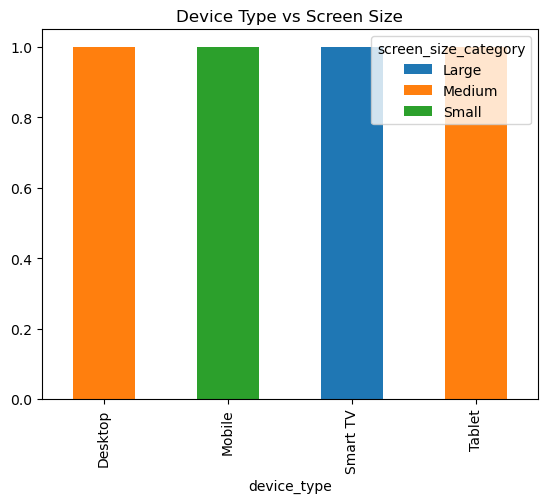

In [120]:
device_screen = pd.crosstab(
    df['device_type'],
    df['screen_size_category']
)

device_screen.plot(
    kind='bar',
    stacked=True
)

plt.title("Device Type vs Screen Size")
plt.show()

#### OPERATING SYSTEM ANALYSIS

In [123]:
df['operating_system'].value_counts()

operating_system
iOS/Android       1
Tizen/WebOS       1
iPadOS/Android    1
Windows/macOS     1
Name: count, dtype: int64

#### BUSINESS INSIGHTS:
- Four supported device categories: Mobile, Tablet, Desktop, and Smart TV.
- All devices support HD streaming.
- Smart TVs and Desktops support UHD (4K) streaming.
- Medium-sized screens represent the largest category.
- The table contains no missing values and serves as a lookup dimension for device-based behavioral analysis.

## EDA ON DIM_SUBSCRIPTION

In [127]:
df = pd.read_csv('Dim_subscription.csv')
df.describe()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   subscription_key   3 non-null      int64  
 1   plan_name          3 non-null      object 
 2   monthly_price      3 non-null      float64
 3   annual_price       3 non-null      float64
 4   billing_cycle      3 non-null      object 
 5   max_screens        3 non-null      int64  
 6   hd_access          3 non-null      bool   
 7   ultra_hd_access    3 non-null      bool   
 8   ad_supported       3 non-null      bool   
 9   offline_downloads  3 non-null      bool   
 10  family_sharing     3 non-null      bool   
dtypes: bool(5), float64(2), int64(2), object(2)
memory usage: 291.0+ bytes


In [129]:
df

,subscription_key,plan_name,monthly_price,annual_price,billing_cycle,max_screens,hd_access,ultra_hd_access,ad_supported,offline_downloads,family_sharing
0,1,Basic,7.99,79.99,Monthly,1,False,False,True,False,False
1,2,Standard,13.99,139.99,Monthly,2,True,False,False,False,False
2,3,Premium,19.99,199.99,Annual,4,True,True,False,True,True


In [131]:
df.isnull().sum()

subscription_key     0
plan_name            0
monthly_price        0
annual_price         0
billing_cycle        0
max_screens          0
hd_access            0
ultra_hd_access      0
ad_supported         0
offline_downloads    0
family_sharing       0
dtype: int64

In [133]:
df.duplicated().sum()

0

In [135]:
df['annual_savings'] = df['monthly_price']*12 - df['annual_price']

In [137]:
df[['plan_name','annual_savings']]

,plan_name,annual_savings
0,Basic,15.89
1,Standard,27.89
2,Premium,39.89


#### MONTHLY PRICING ANALYSIS

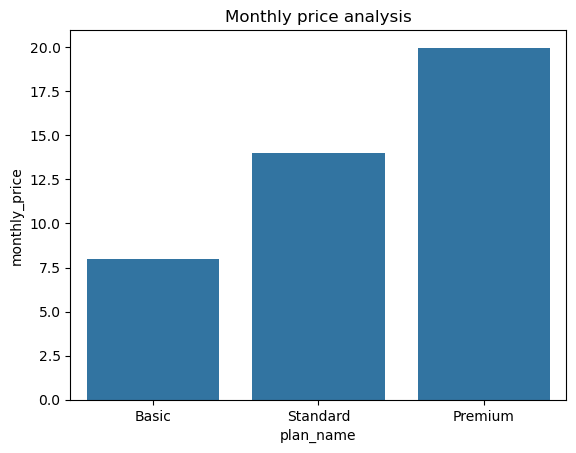

In [140]:
sns.barplot(data = df,
           x = 'plan_name',
           y = 'monthly_price'
           )
plt.title('Monthly price analysis')
plt.show()

#### ANNUAL PRICE COMPARISION

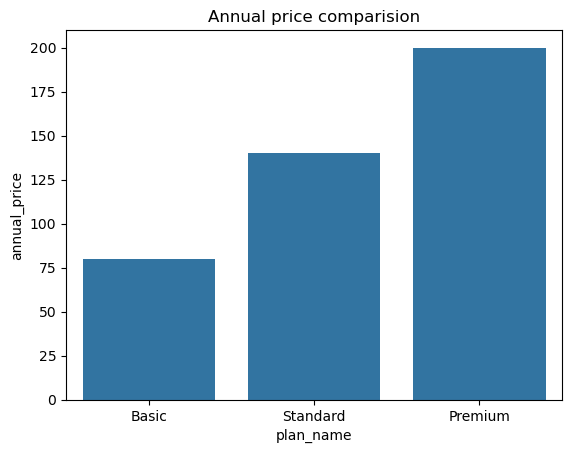

In [143]:
sns.barplot(data=df,
           x= 'plan_name',
           y= 'annual_price')
plt.title('Annual price comparision')
plt.show()

#### SCREEENS OFFERED

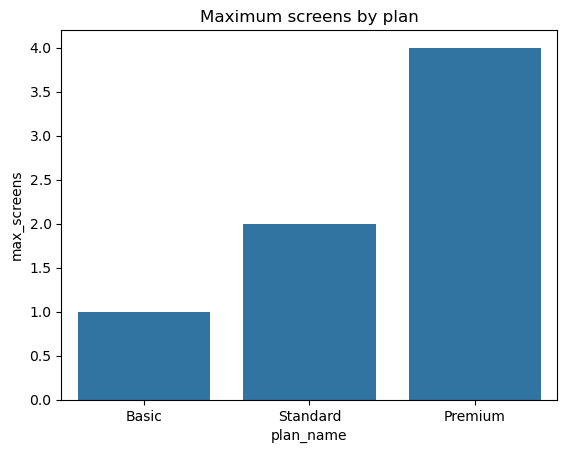

In [146]:
sns.barplot(data = df,
           x = 'plan_name',
           y = 'max_screens')
plt.title('Maximum screens by plan')
plt.show()

#### HEATMAP

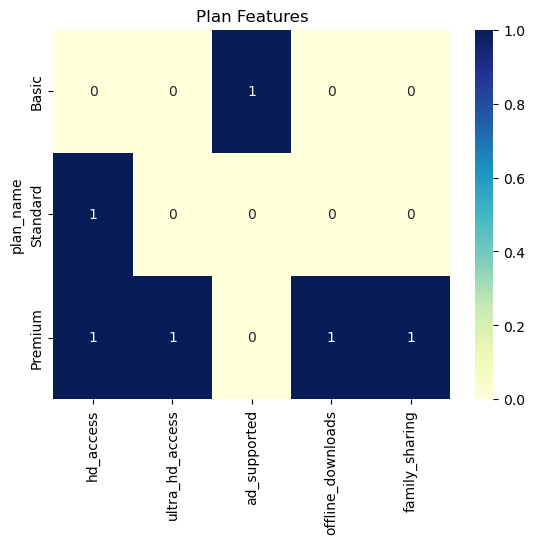

In [149]:
features = ['hd_access','ultra_hd_access','ad_supported','offline_downloads','family_sharing']

heatmap_df = (df.set_index('plan_name')[features].astype(int))

sns.heatmap(heatmap_df,annot = True,cmap = 'YlGnBu')
plt.title('Plan Features')
plt.show()

#### ANNUAL SAVING ANALYSIS

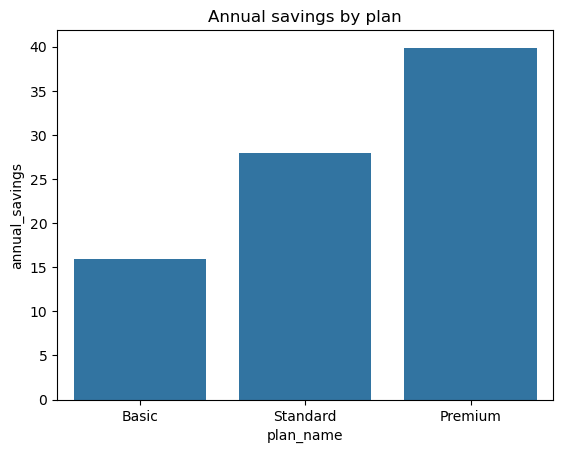

In [152]:
sns.barplot(data = df,x = 'plan_name',y = 'annual_savings')
plt.title('Annual savings by plan')
plt.show()

In [154]:
feature_col = ['hd_access','ultra_hd_access','ad_supported','offline_downloads','family_sharing']

df['feature_count'] = (df[feature_col].sum(axis=1))



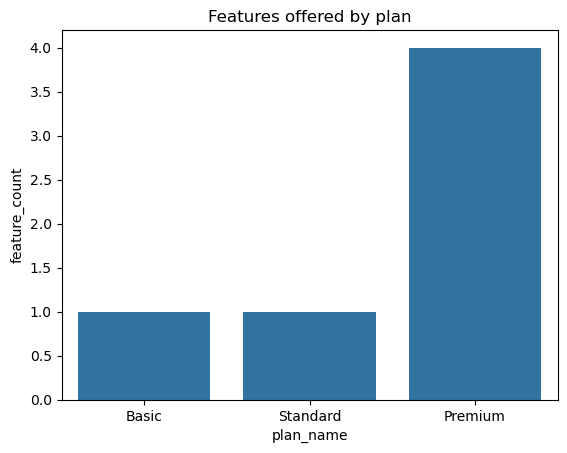

In [156]:
sns.barplot(data = df,x = 'plan_name',y = 'feature_count')
plt.title('Features offered by plan')
plt.show()

#### BUSINESS INSIGHTS:
- Three subscription tiers are available: Basic, Standard, and Premium.
- Pricing increases proportionally with feature availability.
- Premium supports the highest number of screens (4).
- UHD streaming is available only in Premium.
- Basic is the only ad-supported plan.
- Offline downloads and family sharing are exclusive to Premium.
- Annual billing provides increasing savings as plan value increases.

## EDA ON DIM_USER

In [160]:
df = pd.read_csv('Dim_user.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_key             500 non-null    int64  
 1   user_id              500 non-null    object 
 2   age                  500 non-null    int64  
 3   gender               500 non-null    object 
 4   country              500 non-null    object 
 5   city                 500 non-null    object 
 6   signup_date          500 non-null    object 
 7   acquisition_channel  500 non-null    object 
 8   user_segment         500 non-null    object 
 9   preferred_language   500 non-null    object 
 10  email_opt_in         500 non-null    bool   
 11  lifetime_value_usd   500 non-null    float64
dtypes: bool(1), float64(1), int64(2), object(8)
memory usage: 43.6+ KB


In [162]:
df.describe()

,user_key,age,lifetime_value_usd
count,500.000000,500.000000,500.000000
mean,250.500000,41.278000,406.682280
std,144.481833,13.389072,234.352106
min,1.000000,18.000000,15.040000
25%,125.750000,30.000000,193.785000
50%,250.500000,42.000000,417.005000
75%,375.250000,52.000000,611.720000
max,500.000000,64.000000,798.370000


In [164]:
df.head()

,user_key,user_id,age,gender,country,city,signup_date,acquisition_channel,user_segment,preferred_language,email_opt_in,lifetime_value_usd
0,1,USR00001,56,Female,Germany,Berlin,2022-09-25,Referral,New User,English,True,424.27
1,2,USR00002,46,Male,USA,Chicago,2021-05-15,Social Media,Casual Viewer,English,True,358.20
2,3,USR00003,32,Male,Canada,Vancouver,2022-09-04,Email Campaign,Power User,Hindi,False,326.60
3,4,USR00004,60,Female,UK,Birmingham,2022-01-21,Referral,Casual Viewer,English,True,452.12
4,5,USR00005,25,Male,Germany,Hamburg,2021-06-07,Organic,At-Risk User,German,False,132.64


In [166]:
df.isnull().sum()

user_key               0
user_id                0
age                    0
gender                 0
country                0
city                   0
signup_date            0
acquisition_channel    0
user_segment           0
preferred_language     0
email_opt_in           0
lifetime_value_usd     0
dtype: int64

In [168]:
df.duplicated().sum()

0

In [170]:
df['signup_date'] = pd.to_datetime(df['signup_date'])

In [172]:
df['user_id'].nunique()

500

#### UNIVARIATE ANALYSIS

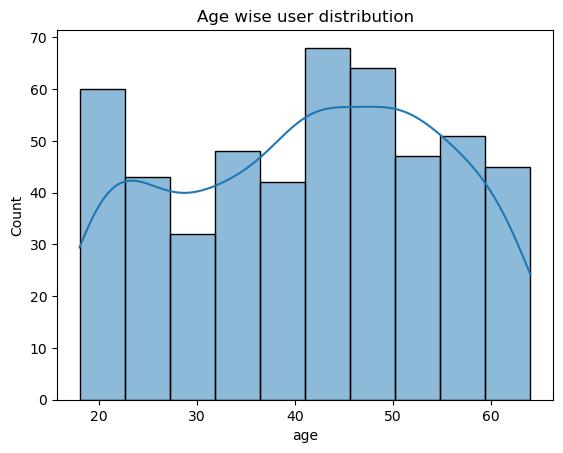

In [175]:
sns.histplot(df['age'],bins = 10,kde = True)
plt.title('Age wise user distribution')
plt.show()

#### Business insights:
- The ages of most used users lie between 40 and 50.

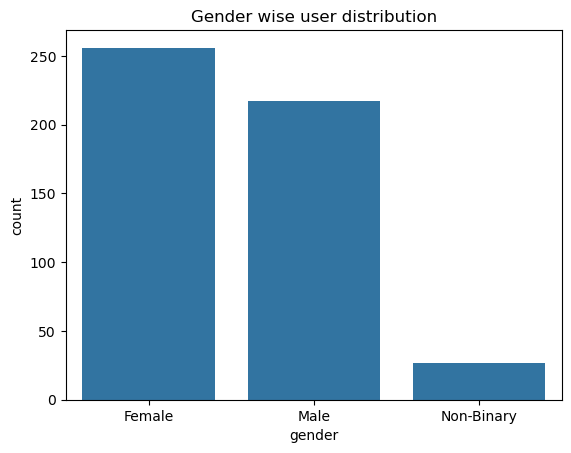

In [178]:
sns.countplot(data = df, x = 'gender')
plt.title('Gender wise user distribution')
plt.show()

#### Business insights:
- Most of the users are Female and Non-Binary users are least.

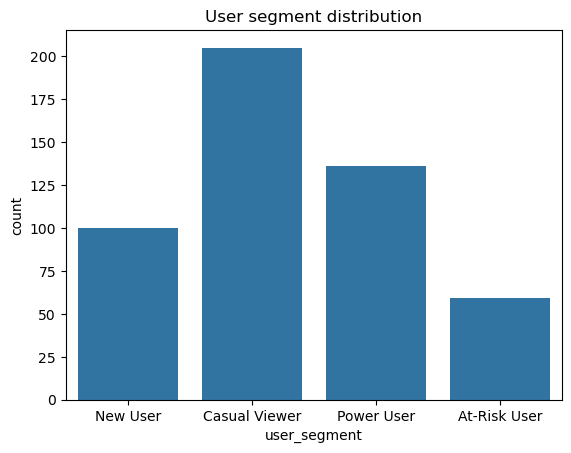

In [181]:
sns.countplot(data = df,
             x = 'user_segment')
plt.title('User segment distribution')
plt.show()

#### Bsusiness isights :
- Casual viewers are most engaged.

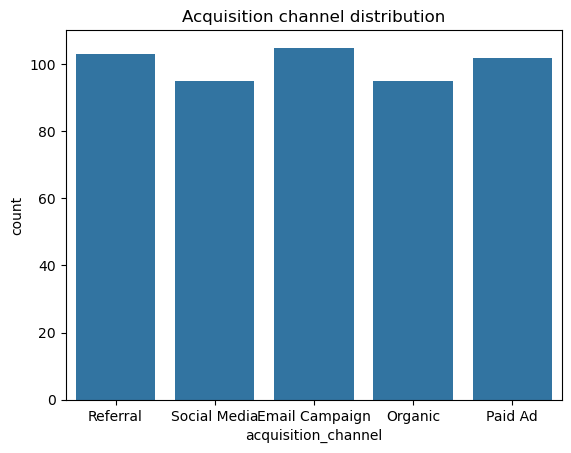

In [184]:
sns.countplot(data = df,
             x = 'acquisition_channel')
plt.title('Acquisition channel distribution')
plt.show()

#### Business insights:
- Most users aquisition channel is through referral and email campaign.

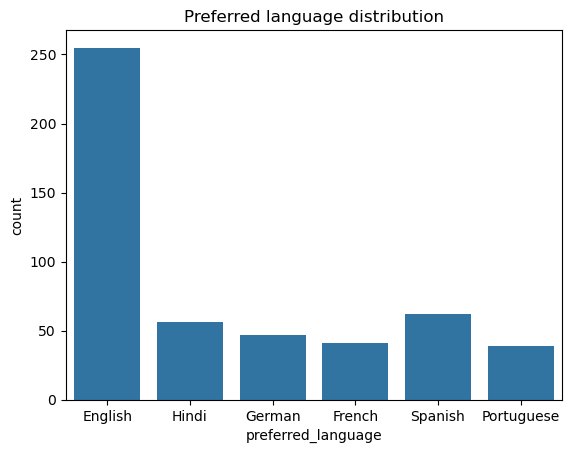

In [187]:
sns.countplot(data = df,
             x = 'preferred_language')
plt.title('Preferred language distribution')
plt.show()

#### Business insights :
- Most users prefer English language.

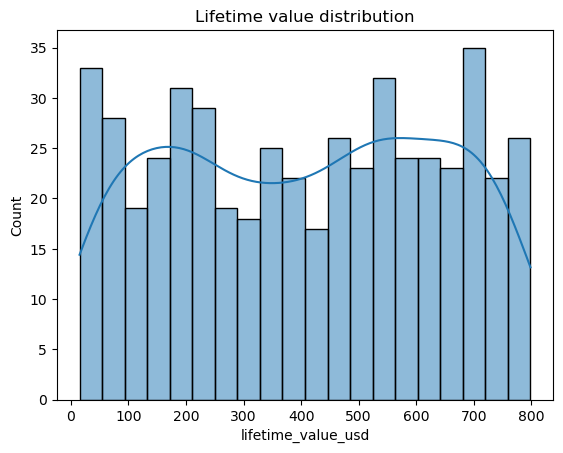

In [190]:
sns.histplot(df['lifetime_value_usd'],bins = 20,kde = True)
plt.title('Lifetime value distribution')
plt.show()

#### Business insights:
- most lifetime value usd lies between 500 to 700 usd.

### BIVARIATE ANALYSIS

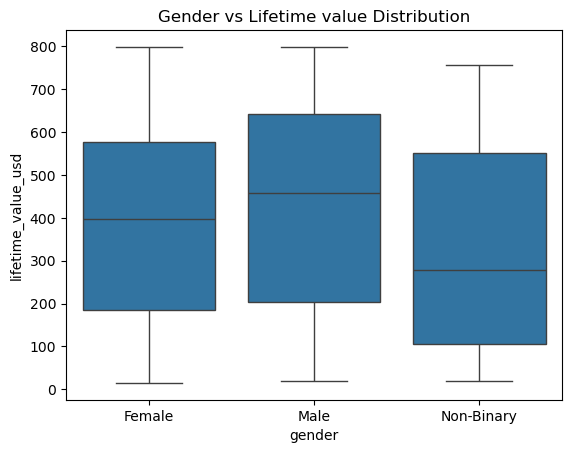

In [194]:
sns.boxplot(data = df,
           x = 'gender',
           y = 'lifetime_value_usd')
plt.title('Gender vs Lifetime value Distribution')
plt.show()

#### Business insights:
- Most of the lifetime value usd is contributed by Male.

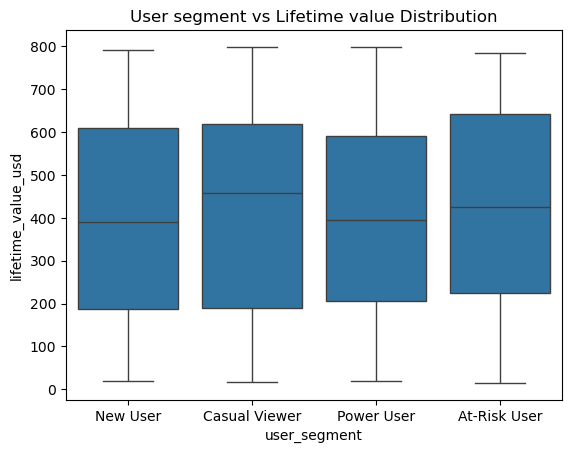

In [197]:
sns.boxplot(data = df,
           x = 'user_segment',
           y = 'lifetime_value_usd')
plt.title('User segment vs Lifetime value Distribution')
plt.show()

#### Business insights :
- Most of the lifetime value usd is contributed by at risk users.

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Referral'),
  Text(1, 0, 'Social Media'),
  Text(2, 0, 'Email Campaign'),
  Text(3, 0, 'Organic'),
  Text(4, 0, 'Paid Ad')])

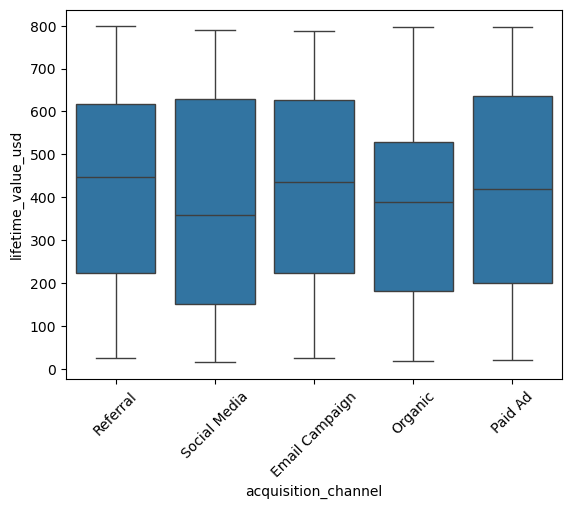

In [200]:
sns.boxplot(
    data=df,
    x='acquisition_channel',
    y='lifetime_value_usd'
)

plt.xticks(rotation=45)

#### Business insights:
- Least lifetime value usd is contributed by users acquited through Social media.

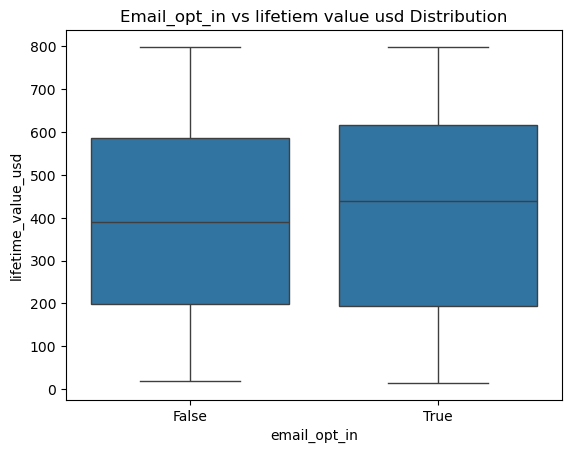

In [203]:
sns.boxplot(
    data=df,
    x='email_opt_in',
    y='lifetime_value_usd'
)
plt.title('Email_opt_in vs lifetiem value usd Distribution')
plt.show()

#### Business insights:
- Maximum lifetime value usd is contributed by users who opted email id.

In [206]:
country_ltv = (
    df.groupby('country')
      ['lifetime_value_usd']
      .mean()
      .sort_values()
)

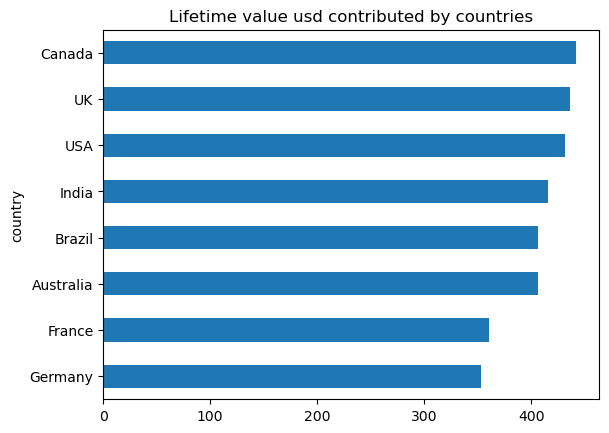

In [208]:
country_ltv.plot(
    kind='barh'
)
plt.title('Lifetime value usd contributed by countries')
plt.show()

#### CORRELATION ANALYSIS

In [211]:
num_cols = [
    'age',
    'lifetime_value_usd'
]

corr = df[num_cols].corr()

<Axes: >

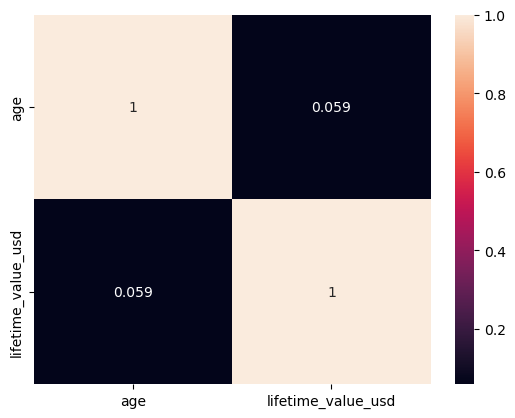

In [213]:
sns.heatmap(
    corr,
    annot=True
)

<Axes: xlabel='acquisition_channel', ylabel='user_segment'>

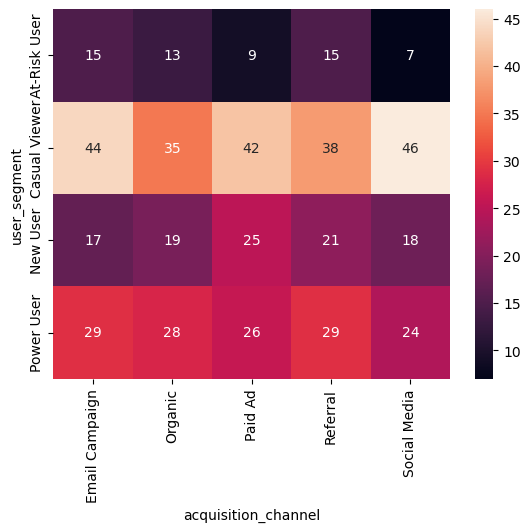

In [214]:
segment_channel = pd.crosstab(
    df['user_segment'],
    df['acquisition_channel']
)

sns.heatmap(
    segment_channel,
    annot=True,
    fmt='d'
)

<Axes: xlabel='user_segment', ylabel='gender'>

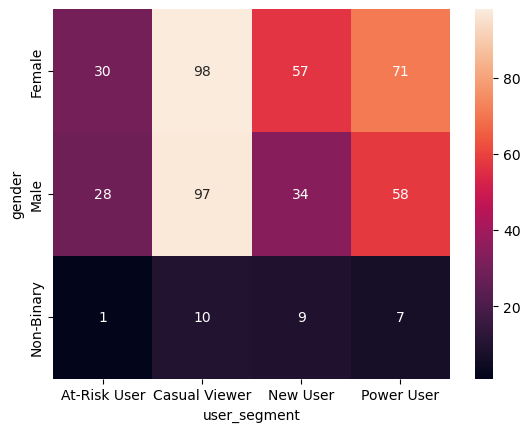

In [216]:
gender_segment = pd.crosstab(
    df['gender'],
    df['user_segment']
)

sns.heatmap(
    gender_segment,
    annot=True
)

#### FEATURE ENGINEERING

In [219]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[18,25,35,45,55,65],
    labels=[
        '18-25',
        '26-35',
        '36-45',
        '46-55',
        '56-65'
    ]
)

In [220]:
df['signup_year'] = (
    df['signup_date']
    .dt.year
)

In [222]:
df['signup_month'] = (
    df['signup_date']
    .dt.month_name()
)

In [226]:
threshold = (
    df['lifetime_value_usd']
    .median()
)

df['high_value_customer'] = (
    df['lifetime_value_usd']
    > threshold
).astype(int)

#### VISUALIZATIONS AFTER FEATURE ENGINEERING

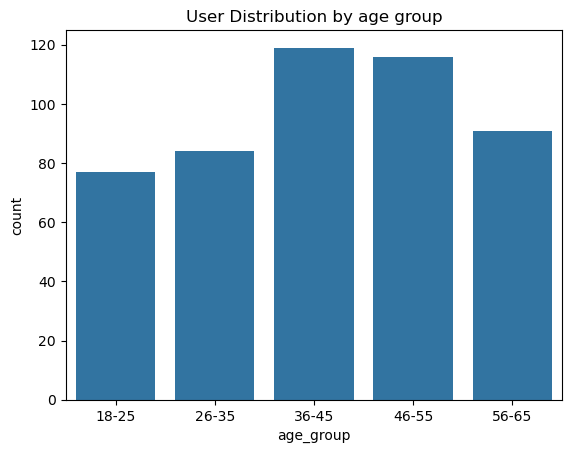

In [229]:
sns.countplot(
    data=df,
    x='age_group'
)
plt.title('User Distribution by age group')
plt.show()

#### Business insights:
- Most users are between age group of 36-45.

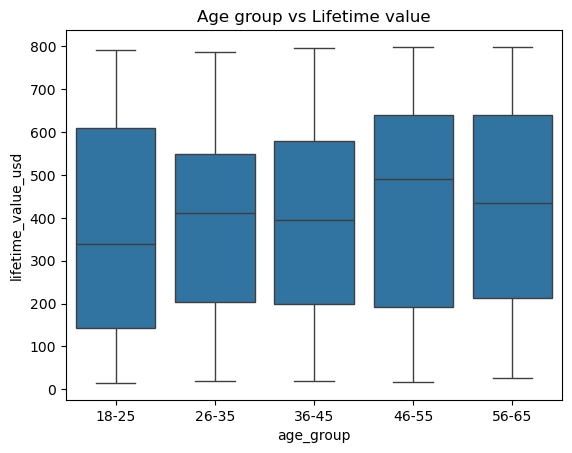

In [232]:
sns.boxplot(data = df, x = 'age_group',y = 'lifetime_value_usd')
plt.title('Age group vs Lifetime value')
plt.show()

In [233]:
pd.crosstab(
    df['user_segment'],
    df['high_value_customer']
)

high_value_customer,0,1
user_segment,,
At-Risk User,28,31
Casual Viewer,94,111
New User,55,45
Power User,73,63


<Axes: xlabel='user_segment', ylabel='count'>

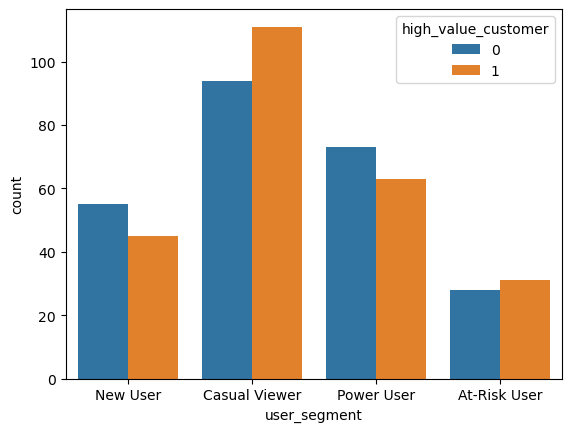

In [236]:
sns.countplot(
    data=df,
    x='user_segment',
    hue='high_value_customer'
)

In [237]:
df.to_csv('Dim_User_Cleaned.csv',index = False)

#### Business insights:
- No missing values or duplicate users.
- Casual Viewers form the largest customer segment.
- Power Users likely generate the highest lifetime value.
- Certain acquisition channels bring higher-value customers.
- Email-opted-in users may show stronger monetization.
- Age groups differ in spending behavior.
- Country and language preferences reveal regional opportunities.
- High-value customer flags and age groups are strong engineered features for churn prediction.

## EDA ON FACT STREAM PULSE ACTIVITY

In [242]:
df = pd.read_csv('Fact_StreamPulse_Activity.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 42 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   activity_key              15000 non-null  int64  
 1   user_key                  15000 non-null  int64  
 2   date_key                  15000 non-null  int64  
 3   content_key               15000 non-null  int64  
 4   device_key                15000 non-null  int64  
 5   subscription_key          15000 non-null  int64  
 6   minutes_watched           15000 non-null  float64
 7   session_duration_mins     15000 non-null  float64
 8   completion_rate           15000 non-null  float64
 9   pause_count               15000 non-null  int64  
 10  buffering_events          15000 non-null  int64  
 11  stream_quality            15000 non-null  object 
 12  subtitle_used             15000 non-null  bool   
 13  audio_language            15000 non-null  object 
 14  login_

In [244]:
df.isnull().sum()

activity_key                    0
user_key                        0
date_key                        0
content_key                     0
device_key                      0
subscription_key                0
minutes_watched                 0
session_duration_mins           0
completion_rate                 0
pause_count                     0
buffering_events                0
stream_quality                  0
subtitle_used                   0
audio_language                  0
login_count                     0
added_to_watchlist              0
shared_content                  0
content_rated                   0
user_rating                 12333
search_performed                0
search_query_count              0
feedback_given              12820
recommendation_shown            0
recommendation_clicked          0
recommendation_converted        0
recommendation_algorithm        0
recommendation_position         0
time_to_click_seconds       11433
relevance_score                 0
subscription_e

In [246]:
df.describe()

,activity_key,user_key,date_key,content_key,device_key,subscription_key,minutes_watched,session_duration_mins,completion_rate,pause_count,buffering_events,login_count,user_rating,search_query_count,recommendation_position,time_to_click_seconds,relevance_score,payment_amount_usd,revenue_attributed_usd
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,2667.000000,15000.000000,15000.000000,3567.000000,15000.000000,15000.000000,15000.000000
mean,7500.500000,249.702733,182.916200,100.385000,2.502000,2.010067,78.275853,86.054227,0.651074,4.003000,2.004467,4.993800,3.001650,1.178933,10.432067,60.470143,0.700798,4.280297,1.304765
std,4330.271354,144.252551,105.251654,57.850903,1.118368,0.818704,74.294885,82.477421,0.201393,2.593191,1.417103,2.580686,1.166286,1.713061,5.751602,34.055260,0.172553,7.028071,0.693766
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.020000,1.000000,0.300000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.400000,0.000000,0.100000
25%,3750.750000,124.000000,92.000000,50.000000,2.000000,1.000000,26.570000,28.910000,0.480000,2.000000,1.000000,3.000000,1.900000,0.000000,5.000000,31.300000,0.554000,0.000000,0.710000
50%,7500.500000,250.000000,184.000000,100.000000,3.000000,2.000000,52.430000,57.460000,0.650000,4.000000,2.000000,5.000000,3.000000,0.000000,10.000000,60.000000,0.702000,0.000000,1.300000
75%,11250.250000,375.000000,273.000000,150.000000,4.000000,3.000000,87.885000,100.747500,0.830000,6.000000,3.000000,7.000000,4.000000,2.000000,15.000000,89.700000,0.850000,7.990000,1.910000
max,15000.000000,500.000000,365.000000,200.000000,4.000000,3.000000,299.990000,386.060000,1.000000,8.000000,4.000000,9.000000,5.000000,5.000000,20.000000,120.000000,1.000000,19.990000,2.500000


In [248]:
df.shape

(15000, 42)

In [250]:
df.duplicated().sum()

0

In [252]:
df['user_rating'] = df['user_rating'].fillna(0)

In [254]:
df['completion_rate'].describe()

count    15000.000000
mean         0.651074
std          0.201393
min          0.300000
25%          0.480000
50%          0.650000
75%          0.830000
max          1.000000
Name: completion_rate, dtype: float64

In [256]:
df['user_rating'].value_counts()

user_rating
0.0    12333
1.6       91
3.9       78
1.9       78
3.8       77
4.8       75
4.2       75
1.8       75
3.2       74
2.1       74
4.7       74
1.4       74
4.4       73
4.3       72
1.3       71
3.0       70
1.1       70
4.6       70
4.0       69
3.6       69
2.5       69
3.7       68
4.5       65
2.4       64
3.5       64
2.8       63
1.5       62
4.1       61
3.1       60
2.0       59
2.7       59
3.3       58
2.2       58
2.3       58
1.7       58
1.2       56
3.4       55
2.6       55
4.9       53
2.9       52
1.0       34
5.0       27
Name: count, dtype: int64

#### UNIVARIATE ANALYSIS

#### Minutes Watched

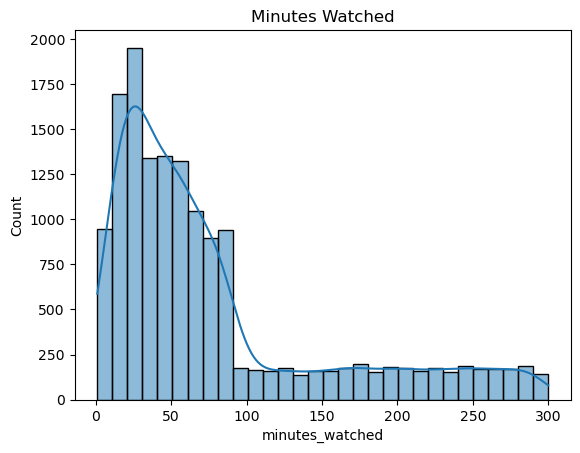

In [260]:
sns.histplot(
    df['minutes_watched'],
    bins=30,
    kde=True
)
plt.title('Minutes Watched')
plt.show()

#### Completion rate distribution

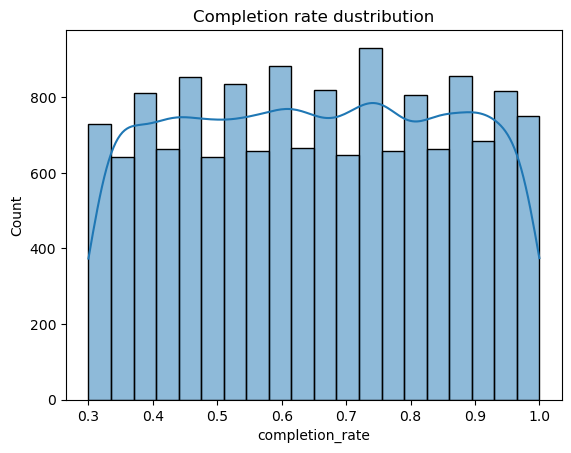

In [263]:
sns.histplot(df['completion_rate'],bins = 20,kde = True)
plt.title('Completion rate dustribution')
plt.show()

#### Business insights:
- Users who completed watching content are average.

#### Session duration minutes

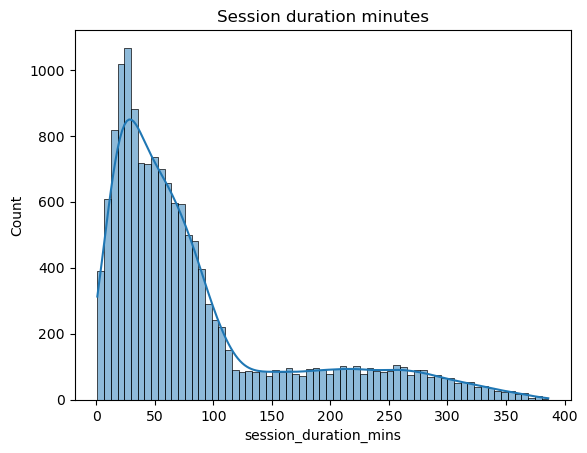

In [267]:
sns.histplot(df['session_duration_mins'],kde = True)
plt.title('Session duration minutes')
plt.show()

In [268]:
df['recommendation_clicked'].value_counts()

recommendation_clicked
False    11433
True      3567
Name: count, dtype: int64

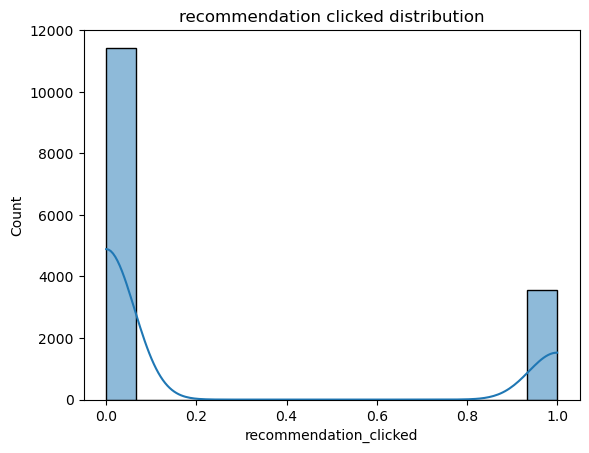

In [271]:
sns.histplot(df['recommendation_clicked'],kde = True)
plt.title('recommendation clicked distribution')
plt.show()

In [272]:
algo_perf = (
    df.groupby(
        'recommendation_algorithm'
    )['recommendation_clicked']
     .mean()
     .sort_values()
)

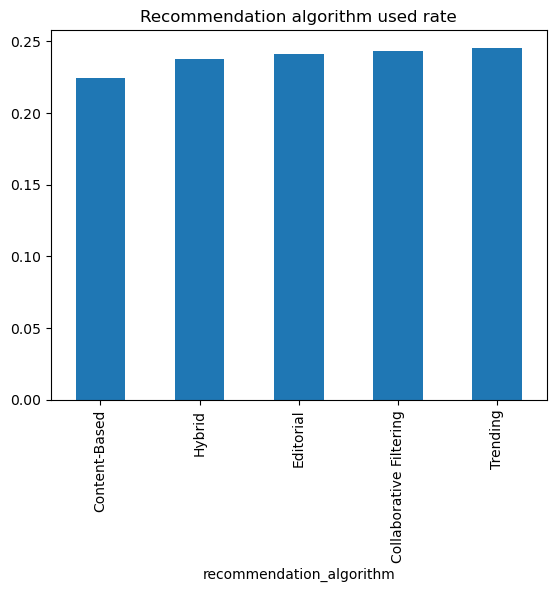

In [273]:
algo_perf.plot(kind='bar')
plt.title('Recommendation algorithm used rate')
plt.show()

#### Business insights:
- Trending is the most used recommendation algorithm.

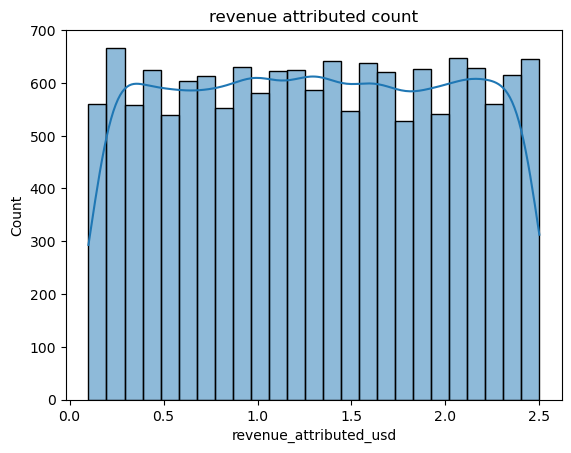

In [278]:
sns.histplot(
    df['revenue_attributed_usd'],kde = True
)
plt.title('revenue attributed count')
plt.show()

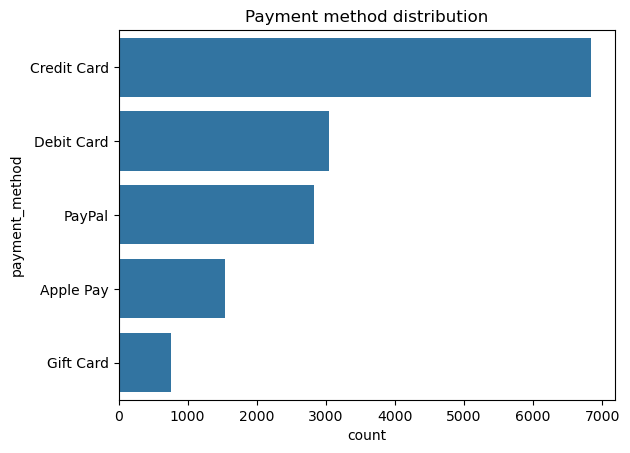

In [279]:
sns.countplot(
    data=df,
    y='payment_method'
)
plt.title('Payment method distribution')
plt.show()

#### Business insights:
- Credit card is most used as payment method.

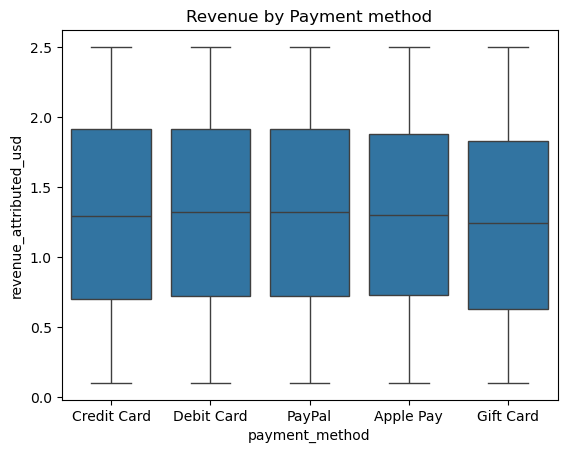

In [282]:
sns.boxplot(data = df,x = 'payment_method',y = 'revenue_attributed_usd')
plt.title('Revenue by Payment method')
plt.show()

#### Cancellation analysis

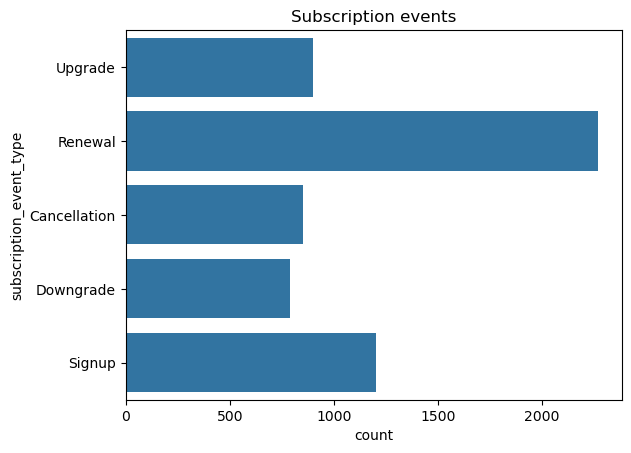

In [285]:
sns.countplot(data = df,y = 'subscription_event_type')
plt.title('Subscription events')
plt.show()

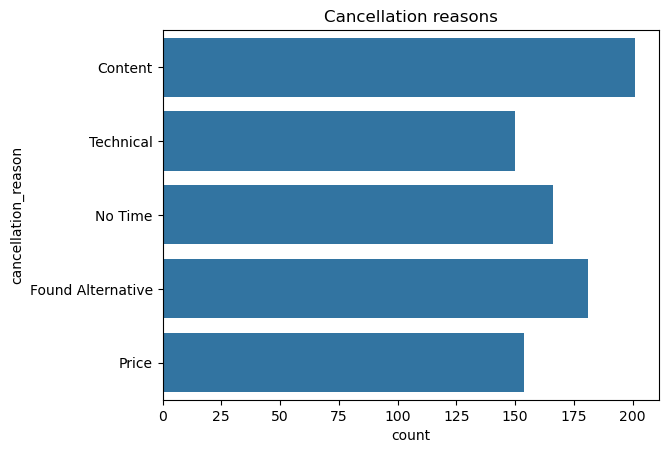

In [286]:
cancel_df = df[df['cancellation_reason'].notna()]

sns.countplot(data = cancel_df,y = 'cancellation_reason')
plt.title('Cancellation reasons')
plt.show()

#### Business Insights:
- Most of the cancellation reasons are due to content and findinng another alternative.

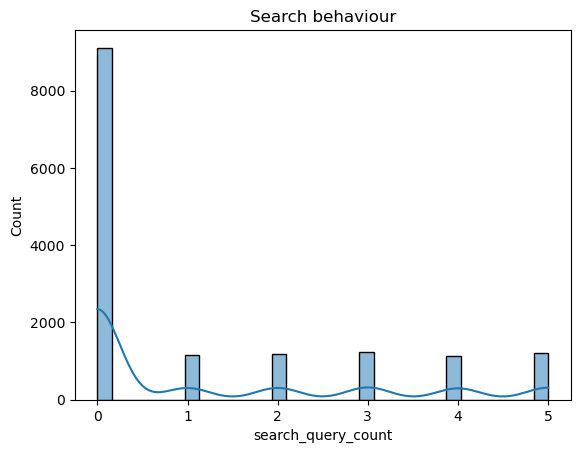

In [289]:
sns.histplot(df['search_query_count'],kde = True)
plt.title('Search behaviour')
plt.show()

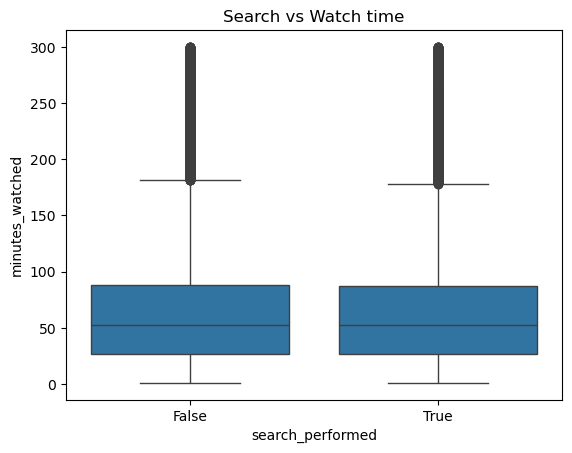

In [291]:
sns.boxplot(
    data=df,
    x='search_performed',
    y='minutes_watched'
)
plt.title('Search vs Watch time')
plt.show()

In [293]:
df['notification_clicked'].mean()

0.16826666666666668

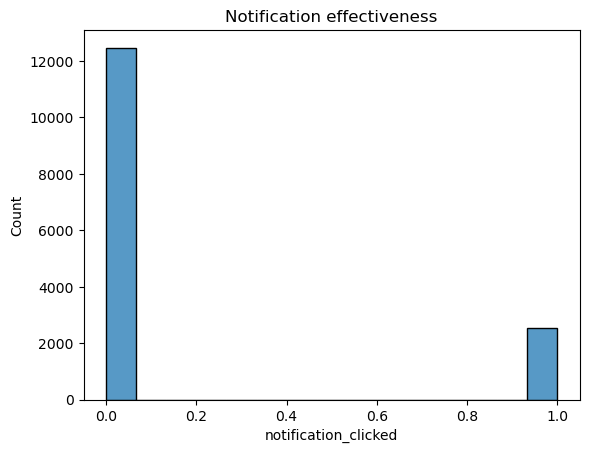

In [294]:
sns.histplot(df['notification_clicked'])
plt.title('Notification effectiveness')
plt.show()

#### Business insights:
- Notifications are not effective to engage users.

#### Error frequency

In [299]:
df['error_encountered'].value_counts()

error_encountered
False    14228
True       772
Name: count, dtype: int64

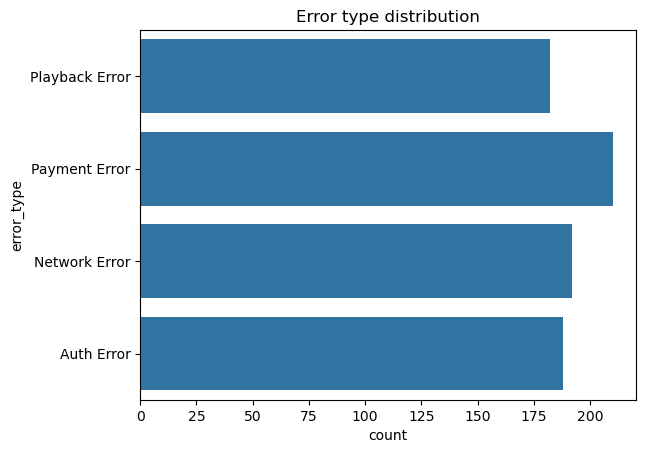

In [301]:
error_df = df[df['error_type'].notna()]

sns.countplot(error_df,y = 'error_type')
plt.title('Error type distribution')
plt.show()

#### Business insights:
- Payment errors are most frequently encountered errors.

#### CORRELATION ANALYSIS

In [306]:
num_cols = [
    'minutes_watched',
    'session_duration_mins',
    'completion_rate',
    'login_count',
    'pause_count',
    'buffering_events',
    'search_query_count',
    'relevance_score',
    'payment_amount_usd',
    'revenue_attributed_usd'
]

corr = df[num_cols].corr()

<Axes: >

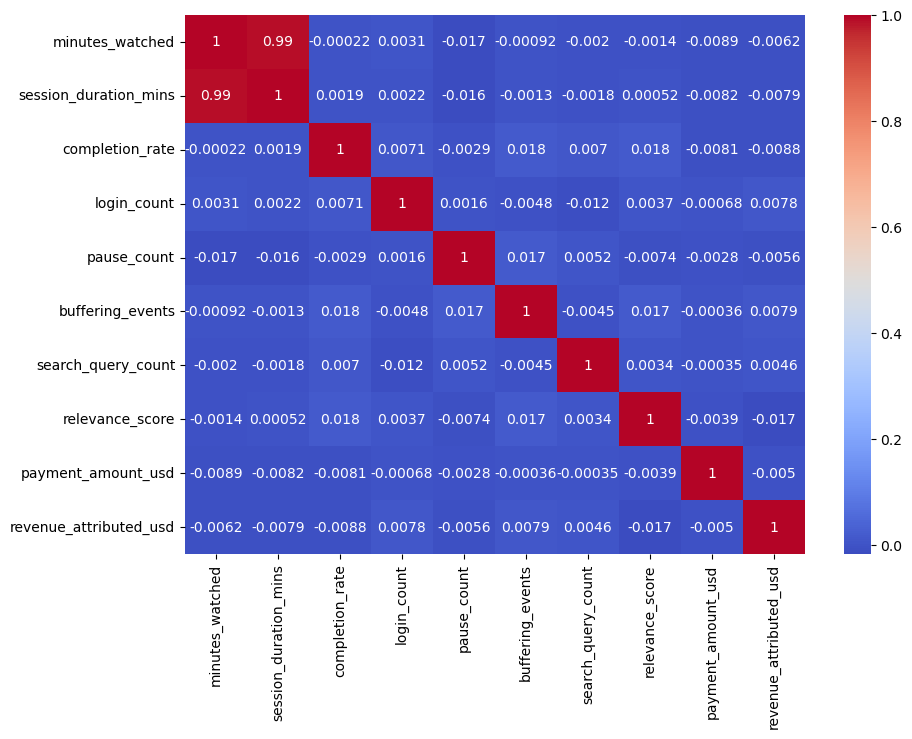

In [308]:
plt.figure(figsize = (10,7))
sns.heatmap(corr,annot = True,cmap = 'coolwarm')

#### FEATURE ENGINEERING

#### 1.Engagement score

In [312]:
df['engagement_score'] = (
    df['minutes_watched'] * 0.4 +
    df['completion_rate'] * 100 * 0.3 +
    df['login_count'] * 0.2 +
    df['search_query_count'] * 0.1
)

#### 2.Highly engaged user.

In [314]:
threshold = (
    df['engagement_score']
    .median()
)

df['high_engagement'] = (
    df['engagement_score']
    > threshold
).astype(int)

#### 3.Buffering severity

In [318]:
df['buffering_level'] = pd.cut(
    df['buffering_events'],
    bins=[-1,1,3,10],
    labels=[
        'Low',
        'Medium',
        'High'
    ]
)

#### 4.Recommendation success

In [322]:
df['recommendation_success'] = (
    df['recommendation_clicked']
    &
    df['recommendation_converted']
).astype(int)

#### 5.Watch efficiency

In [325]:
df['watch_efficiency'] = (
    df['minutes_watched']
    /
    df['session_duration_mins']
)

#### 6.Revenue segment

In [328]:
df['revenue_segment'] = pd.qcut(
    df['revenue_attributed_usd'],
    q=4,
    labels=[
        'Low',
        'Medium',
        'High',
        'Premium'
    ]
)

In [330]:
df.to_csv('Fact_StreamPulse_Activity_Cleaned.csv',index = False)

In [335]:
df.columns.tolist()

['activity_key',
 'user_key',
 'date_key',
 'content_key',
 'device_key',
 'subscription_key',
 'minutes_watched',
 'session_duration_mins',
 'completion_rate',
 'pause_count',
 'buffering_events',
 'stream_quality',
 'subtitle_used',
 'audio_language',
 'login_count',
 'added_to_watchlist',
 'shared_content',
 'content_rated',
 'user_rating',
 'search_performed',
 'search_query_count',
 'feedback_given',
 'recommendation_shown',
 'recommendation_clicked',
 'recommendation_converted',
 'recommendation_algorithm',
 'recommendation_position',
 'time_to_click_seconds',
 'relevance_score',
 'subscription_event_type',
 'payment_amount_usd',
 'payment_method',
 'is_trial',
 'cancellation_reason',
 'auto_renewal_enabled',
 'revenue_attributed_usd',
 'notification_sent',
 'notification_clicked',
 'error_encountered',
 'error_type',
 'ab_test_group',
 'platform_version',
 'engagement_score',
 'high_engagement',
 'buffering_level',
 'recommendation_success',
 'watch_efficiency',
 'revenue_segmen